# 13.2 文本分类与词嵌入（2课时）

> **NOAI 竞赛课程 · 模块十三：自然语言处理**

---

## 本节目标

| 知识点 | 掌握程度 |
|--------|----------|
| One-hot 编码及其局限 | ⭐⭐⭐ |
| 词的分布式表示 | ⭐⭐⭐ |
| Word2Vec（CBOW / Skip-gram） | ⭐⭐⭐ |
| GloVe / FastText | ⭐⭐ |
| PyTorch nn.Embedding | ⭐⭐⭐ |
| 词袋模型 BoW | ⭐⭐ |
| TF-IDF | ⭐⭐⭐ |
| 端到端文本分类实战 | ⭐⭐⭐ |

---

## 一、词的表示方法

### 1.1 One-Hot 编码

最简单的词表示方法：词汇表大小为 $|V|$，每个词用一个 $|V|$ 维向量表示，仅对应位置为 1，其余为 0。

假设词汇表 `['我', '爱', '自然', '语言']`（$|V|=4$）：

$$\text{我} = [1, 0, 0, 0]^T, \quad \text{爱} = [0, 1, 0, 0]^T, \quad \text{自然} = [0, 0, 1, 0]^T, \quad \text{语言} = [0, 0, 0, 1]^T$$

### One-Hot 的三大缺陷

| 缺陷 | 说明 |
|------|------|
| **维度灾难** | 词汇表通常有数万到数十万词，向量极其稀疏 |
| **语义鸿沟** | 任意两词的向量点积均为 0，无法表达语义相似性 |
| **无法泛化** | 无法利用已知词的信息帮助理解新词 |

In [9]:
import numpy as np

vocab = ['我', '爱', '自然', '语言', '处理', '深度', '学习']
word2id = {w: i for i, w in enumerate(vocab)}

def one_hot(word, vocab):
    vec = np.zeros(len(vocab))
    vec[word2id[word]] = 1
    return vec

print(f"词汇表: {vocab}")
print(f"\nOne-Hot 编码:")
for w in ['我', '爱', '自然', '语言', '处理']:
    vec = one_hot(w, vocab)
    print(f"  {w:4s} → {vec.tolist()}")

# 任意两词的点积
v1, v2 = one_hot('自然', vocab), one_hot('语言', vocab)
print(f"\n任意两个词的点积: {np.dot(v1, v2):.2f}  ← 无法区分相似性！")
print(f"词汇表大小: {len(vocab)}, 向量维度: {len(vocab)}")

词汇表: ['我', '爱', '自然', '语言', '处理', '深度', '学习']

One-Hot 编码:
  我    → [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  爱    → [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  自然   → [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
  语言   → [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]
  处理   → [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]

任意两个词的点积: 0.00  ← 无法区分相似性！
词汇表大小: 7, 向量维度: 7


### 1.2 分布式表示（Distributed Representation）

**核心思想**：用一个**低维稠密向量**表示一个词，语义相近的词在向量空间中距离相近。

> "You shall know a word by the company it keeps." —— J.R. Firth

分布假说：**上下文相似的词，其语义也相似**。

$$
\underbrace{\text{向量空间}}_{d=100\sim300 \text{维}} \quad \text{king} \approx \text{queen}, \quad \text{man} \approx \text{woman}
$$

### 经典词向量类比

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

---

## 二、Word2Vec

Word2Vec 是 Google 于 2013 年提出的词嵌入方法，包含两种模型架构：

### 2.1 CBOW（Continuous Bag-of-Words）

**用上下文预测中心词**

$$P(w_t \mid w_{t-k}, \ldots, w_{t-1}, w_{t+1}, \ldots, w_{t+k})$$

```
训练样本: "The cat sits on the mat"

  上下文: [The, cat,    on,  the]  →  预测: sits
  上下文: [cat, sits,   the, mat]  →  预测: on

     The    cat     sits    on     the    mat
      ↓      ↓       ↑      ↓      ↓
     [context window]  → target word ←
```

### 2.2 Skip-gram

**用中心词预测上下文词**

$$P(w_{t-k}, \ldots, w_{t+k} \mid w_t)$$

```
训练样本: "The cat sits on the mat"

     中心词: sits  →  预测上下文: [The, cat, on, the, mat]

     The    cat     sits    on     the    mat
                    ↓
          target word  → [predict surrounding words]
```

### CBOW vs Skip-gram

| 特性 | CBOW | Skip-gram |
|------|------|-----------|
| 方向 | 上下文 → 中心词 | 中心词 → 上下文 |
| 训练速度 | 较快 | 较慢 |
| 低频词效果 | 较差 | 较好 |
| 适用场景 | 大数据集 | 小数据集 |

In [10]:
import numpy as np

# ===== Skip-gram 概念演示 =====

corpus = "i like deep learning and natural language processing".split()

print("===== Skip-gram 概念演示 =====")
print(f"\n【原始语料】")
print(f"  {corpus}")

# 生成 Skip-gram 训练对
window_size = 2
pairs = []

for i, center in enumerate(corpus):
    for j in range(max(0, i - window_size), min(len(corpus), i + window_size + 1)):
        if i != j:
            pairs.append((center, corpus[j]))

print(f"\n【生成 Skip-gram 训练对 (window={window_size})】")
for center, context in pairs:
    print(f"  ({center:10s}, {context:10s})", end="")
    if pairs.index((center, context)) % 2 == 1:
        print()
    else:
        print(" |  ", end="")

print(f"\n共生成 {len(pairs)} 个训练对")

===== Skip-gram 概念演示 =====

【原始语料】
  ['i', 'like', 'deep', 'learning', 'and', 'natural', 'language', 'processing']

【生成 Skip-gram 训练对 (window=2)】
  (i         , like      ) |    (i         , deep      )
  (like      , i         ) |    (like      , deep      )
  (like      , learning  ) |    (deep      , i         )
  (deep      , like      ) |    (deep      , learning  )
  (deep      , and       ) |    (learning  , like      )
  (learning  , deep      ) |    (learning  , and       )
  (learning  , natural   ) |    (and       , deep      )
  (and       , learning  ) |    (and       , natural   )
  (and       , language  ) |    (natural   , learning  )
  (natural   , and       ) |    (natural   , language  )
  (natural   , processing) |    (language  , and       )
  (language  , natural   ) |    (language  , processing)
  (processing, natural   ) |    (processing, language  )

共生成 26 个训练对


In [11]:
# ===== Word2Vec 简化实现（概念演示）=====

import torch
import torch.nn as nn
import torch.optim as optim

# 词汇表
vocab_list = ['i', 'like', 'deep', 'learning', 'and', 'natural', 'language', 'processing']
word2id = {w: i for i, w in enumerate(vocab_list)}
vocab_size = len(vocab_list)
embed_dim = 8

# Skip-gram 训练数据
skipgram_pairs = []
corpus = vocab_list.copy()
window = 2
for i, center in enumerate(corpus):
    for j in range(max(0, i - window), min(len(corpus), i + window + 1)):
        if i != j:
            skipgram_pairs.append((word2id[center], word2id[corpus[j]]))

# 简单 Skip-gram 模型
class SkipGram(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        # 中心词的嵌入矩阵 (W_in)
        self.center_embeddings = nn.Embedding(vocab_size, embed_dim)
        # 上下文词的嵌入矩阵 (W_out)
        self.context_embeddings = nn.Embedding(vocab_size, embed_dim)
    
    def forward(self, center_ids, context_ids):
        center_emb = self.center_embeddings(center_ids)       # [batch, dim]
        context_emb = self.context_embeddings(context_ids)     # [batch, dim]
        scores = torch.sum(center_emb * context_emb, dim=1)  # [batch]
        return torch.sigmoid(scores)

model = SkipGram(vocab_size, embed_dim)
optimizer = optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.BCELoss()

# 训练
center_ids = torch.LongTensor([p[0] for p in skipgram_pairs])
context_ids = torch.LongTensor([p[1] for p in skipgram_pairs])
labels = torch.ones(len(skipgram_pairs))  # 正样本标签为1

for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(center_ids, context_ids)
    loss = loss_fn(outputs, labels)
    loss.backward()
    optimizer.step()

print("===== Word2Vec 简化模型（Skip-gram + Sigmoid）=====")
print(f"\n词汇表: {vocab_list}")
print(f"嵌入维度: {embed_dim}")

# 展示训练后的嵌入
with torch.no_grad():
    embeddings = model.center_embeddings.weight.numpy()

print(f"\n【训练 50 轮后，部分词的嵌入向量】")
for w in ['i', 'deep', 'learning', 'natural', 'language']:
    vec = embeddings[word2id[w]]
    formatted = ', '.join([f'{v:+.2f}' for v in vec])
    print(f"  {w:10s} → [{formatted}]")

# 计算余弦相似度
def cosine_sim(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)

print(f"\n【词相似度 (余弦相似度)】")
pairs_to_check = [('deep', 'learning'), ('deep', 'i'), ('natural', 'language'), ('natural', 'i')]
for w1, w2 in pairs_to_check:
    sim = cosine_sim(embeddings[word2id[w1]], embeddings[word2id[w2]])
    note = "  ← 语义相近！" if sim > 0.9 else ""
    print(f"  {w1:8s} ↔ {w2:8s} :  {sim:.3f}{note}")

===== Word2Vec 简化模型（Skip-gram + Sigmoid）=====

词汇表: ['i', 'like', 'deep', 'learning', 'and', 'natural', 'language', 'processing']
嵌入维度: 8

【训练 50 轮后，部分词的嵌入向量】
  i          → [+0.00, -2.01, -0.79, +1.49, +0.79, +1.39, +0.25, -0.35]
  deep       → [-1.84, -1.97, -0.08, -0.35, -0.14, +0.38, +1.63, +1.71]
  learning   → [+1.23, -0.98, +0.74, +0.50, -0.01, +0.94, +2.47, -2.21]
  natural    → [+1.56, -0.01, -3.18, -0.45, -0.95, -0.35, -0.09, +0.99]
  language   → [-0.64, -2.26, -1.37, +1.59, +0.12, -0.16, -0.41, +2.36]

【词相似度 (余弦相似度)】
  deep     ↔ learning :  0.004
  deep     ↔ i        :  0.333
  natural  ↔ language :  0.329
  natural  ↔ i        :  0.021


### 2.3 GloVe

**GloVe（Global Vectors）** 由 Stanford 于 2014 年提出，结合了全局矩阵分解和局部上下文窗口的优点。

核心思想：词向量的点积应等于它们共现频率的对数：

$$w_i^T \cdot w_j + b_i + b_j = \log(X_{ij})$$

其中 $X_{ij}$ 是词 $i$ 和词 $j$ 在语料中的共现次数。

损失函数（加权最小二乘）：

$$J = \sum_{i,j=1}^{|V|} f(X_{ij})(w_i^T \cdot w_j + b_i + b_j - \log X_{ij})^2$$

### 2.4 FastText

**FastText**（Facebook, 2016）在 Word2Vec 基础上引入了**子词（subword）信息**：

- 每个词表示为其所有 n-gram 子词的向量和
- 示例：`where` 的 3-gram → `<wh`, `whe`, `her`, `ere`, `re>`
- **优势**：能处理 OOV 词（如未登录词可以由其子词组合推断）

### 词嵌入方法对比

| 方法 | 年份 | 提出者 | 特点 |
|------|------|--------|------|
| Word2Vec | 2013 | Google | 局部上下文窗口，简单高效 |
| GloVe | 2014 | Stanford | 全局共现统计，利用矩阵分解 |
| FastText | 2016 | Facebook | 加入子词信息，处理 OOV |

---

## 三、PyTorch nn.Embedding

### 3.1 嵌入层原理

`nn.Embedding` 本质上是一个**可学习的查找表（Lookup Table）**：

$$\text{Embedding}: \{0, 1, \ldots, |V|-1\} \rightarrow \mathbb{R}^d$$

- 输入：整数索引（token id），形状 $[N]$
- 输出：对应的嵌入向量，形状 $[N, d]$
- 参数矩阵：$|V| \times d$，可随模型训练更新

In [12]:
import torch
import torch.nn as nn

print("===== PyTorch nn.Embedding 演示 =====")

# 创建嵌入层
vocab_size = 10
embed_dim = 4
embedding = nn.Embedding(vocab_size, embed_dim)

print(f"\n词汇表大小: {vocab_size}, 嵌入维度: {embed_dim}")
print(f"参数矩阵形状: {embedding.weight.shape}")

# 输入 token ids，获取嵌入向量
token_ids = torch.LongTensor([2, 5, 8])
embedded = embedding(token_ids)

print(f"\n输入 token ids: {token_ids.tolist()}")
print(f"输出嵌入形状: {embedded.shape}")
print(f"嵌入向量:")
for tid, vec in zip(token_ids.tolist(), embedded):
    formatted = ', '.join([f'{v:+.4f}' for v in vec.tolist()])
    print(f"  id={tid} → [{formatted}]")

print(f"\n嵌入层包含 {vocab_size}×{embed_dim} = {vocab_size*embed_dim} 个可训练参数")
print(f"参数总数: {sum(p.numel() for p in embedding.parameters())}")

===== PyTorch nn.Embedding 演示 =====

词汇表大小: 10, 嵌入维度: 4
参数矩阵形状: torch.Size([10, 4])

输入 token ids: [2, 5, 8]
输出嵌入形状: torch.Size([3, 4])
嵌入向量:
  id=2 → [+0.4128, -0.4834, +0.0796, -1.1686]
  id=5 → [-1.9180, +0.4826, -0.5758, +0.1142]
  id=8 → [-1.9896, -1.5706, -2.1135, +0.3711]

嵌入层包含 10×4 = 40 个可训练参数
参数总数: 40


---

## 四、传统文本表示方法

### 4.1 词袋模型（Bag of Words, BoW）

忽略词序，仅统计每个词出现的次数（或是否出现）。

文档 → 固定长度向量 $[\text{count}(w_1), \text{count}(w_2), \ldots, \text{count}(w_{|V|})]$

**优点**：简单、高效
**缺点**：丢失词序信息、向量稀疏、忽略词的语义

In [13]:
import numpy as np
from collections import Counter

print("===== 词袋模型 BoW =====")

docs = [
    "cat dog bird",
    "dog dog cat",
    "bird bird fish"
]

# 构建词汇表
all_words = []
for doc in docs:
    all_words.extend(doc.split())
vocab = sorted(set(all_words))
word2id = {w: i for i, w in enumerate(vocab)}

print(f"\n【句子】")
for i, d in enumerate(docs):
    print(f"  Doc {i+1}: {d}")

print(f"\n【词汇表】 {vocab}")

# 构建 BoW 矩阵
bow_matrix = np.zeros((len(docs), len(vocab)), dtype=int)
for i, doc in enumerate(docs):
    counts = Counter(doc.split())
    for word, count in counts.items():
        bow_matrix[i, word2id[word]] = count

print(f"\n【BoW 矩阵】")
header = "" + " " * 7
for w in vocab:
    header += f"{w:5s}"
print(header)
for i, row in enumerate(bow_matrix):
    print(f"  Doc {i+1}:  {row.tolist()}")

===== 词袋模型 BoW =====

【句子】
  Doc 1: cat dog bird
  Doc 2: dog dog cat
  Doc 3: bird bird fish

【词汇表】 ['bird', 'cat', 'dog', 'fish']

【BoW 矩阵】
       bird cat  dog  fish 
  Doc 1:  [1, 1, 1, 0]
  Doc 2:  [0, 1, 2, 0]
  Doc 3:  [2, 0, 0, 1]


### 4.2 TF-IDF

**TF-IDF（Term Frequency-Inverse Document Frequency）** 衡量一个词对文档的重要程度。

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

其中：

$$\text{TF}(t, d) = \frac{\text{词 } t \text{ 在文档 } d \text{ 中出现的次数}}{\text{文档 } d \text{ 的总词数}}$$

$$\text{IDF}(t) = \log \frac{N}{1 + |\{d \in D : t \in d\}|}$$

- **TF 高** → 词在文档中频繁出现 → 可能重要
- **IDF 高** → 词在语料库中罕见 → 更具区分度
- 停用词（如 the, is）TF 高但 IDF 低 → TF-IDF 低

In [14]:
import numpy as np
from collections import Counter

print("===== TF-IDF 计算 =====")

docs = [
    "cat dog bird fish",
    "dog cat dog bird",
    "fish fish bird fish"
]

# 词汇表
all_words = set()
for doc in docs:
    all_words.update(doc.split())
vocab = sorted(all_words)
word2id = {w: i for i, w in enumerate(vocab)}
N = len(docs)

print(f"\n【语料】")
for i, d in enumerate(docs):
    print(f"  Doc {i+1}: {d}")

# TF 计算
tf_matrix = np.zeros((N, len(vocab)))
for i, doc in enumerate(docs):
    words = doc.split()
    counts = Counter(words)
    for word, count in counts.items():
        tf_matrix[i, word2id[word]] = count / len(words)

print(f"\n【TF 计算】")
for i, doc in enumerate(docs):
    tf_dict = {w: tf_matrix[i, word2id[w]] for w in doc.split()}
    print(f"  {tf_dict}")

# IDF 计算
idf = np.zeros(len(vocab))
for j, word in enumerate(vocab):
    doc_count = sum(1 for doc in docs if word in doc.split())
    idf[j] = np.log(N / (1 + doc_count))

print(f"\n【IDF 值】")
for w in vocab:
    note = " ← 所有文档都有，无区分度" if idf[word2id[w]] < 0.01 else ""
    print(f"  {w:6s}: {idf[word2id[w]]:6.3f}{note}")

# TF-IDF
tfidf_matrix = tf_matrix * idf

print(f"\n【TF-IDF 矩阵】")
header = "" + " " * 10
for w in vocab:
    header += f"{w:8s}"
print(header)
for i, row in enumerate(tfidf_matrix):
    print(f"  Doc {i+1}:    {['{:7.3f}'.format(v) for v in row]}")

===== TF-IDF 计算 =====

【语料】
  Doc 1: cat dog bird fish
  Doc 2: dog cat dog bird
  Doc 3: fish fish bird fish

【TF 计算】
  {'cat': 0.25, 'dog': 0.25, 'bird': 0.25, 'fish': 0.25}
  {'dog': 0.5, 'cat': 0.25, 'bird': 0.25}
  {'fish': 0.75, 'bird': 0.25}

【IDF 值】
  bird  : -0.288 ← 所有文档都有，无区分度
  cat   :  0.000 ← 所有文档都有，无区分度
  dog   :  0.000 ← 所有文档都有，无区分度
  fish  :  0.000 ← 所有文档都有，无区分度

【TF-IDF 矩阵】
          bird    cat     dog     fish    
  Doc 1:    [' -0.072', '  0.000', '  0.000', '  0.000']
  Doc 2:    [' -0.072', '  0.000', '  0.000', '  0.000']
  Doc 3:    [' -0.072', '  0.000', '  0.000', '  0.000']


---

## 五、文本分类实战：端到端流程

### 5.1 文本分类完整流水线

$$\underbrace{\text{原始文本}}_{\text{sentence}} \xrightarrow{\text{Tokenize}} \underbrace{\text{token 序列}}_{[w_1, w_2, \ldots]} \xrightarrow{\text{Encode}} \underbrace{\text{ID 序列}}_{[3, 7, 2, \ldots]} \xrightarrow{\text{Embedding}} \underbrace{\text{向量矩阵}}_{\mathbb{R}^{n \times d}} \xrightarrow{\text{Model}} \underbrace{\text{预测}}_{P(\text{class})}$$

### 5.2 模型架构

```
Input IDs → Embedding → Mean Pooling → Linear → Softmax → Class
           [n, L]      [n, d]     [n, d]      [n, C]    [n, C]
```

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter

print("===== 端到端文本分类实战 =====")

# ===== 1. 准备数据 =====
train_data = [
    ("this movie is great and amazing", 1),   # 正面
    ("i love this wonderful film", 1),         # 正面
    ("this is terrible and boring", 0),        # 负面
    ("the worst movie i have seen", 0),       # 负面
]

test_data = [
    "this film is great",
    "the worst boring film"
]

# 构建词汇表
all_text = ' '.join([t for t, _ in train_data] + test_data)
all_words = sorted(set(all_text.split()))
word2id = {w: i+2 for i, w in enumerate(all_words)}  # 0=pad, 1=unk
PAD_IDX, UNK_IDX = 0, 1

print(f"\n【训练数据】")
for text, label in train_data:
    sentiment = "正面" if label == 1 else "负面"
    print(f"  {sentiment}: '{text}'")

# ===== 2. 定义模型 =====
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc = nn.Linear(embed_dim, num_classes)
    
    def forward(self, x):
        # x: [batch, seq_len]
        embedded = self.embedding(x)         # [batch, seq_len, embed_dim]
        pooled = embedded.mean(dim=1)        # [batch, embed_dim]  均值池化
        logits = self.fc(pooled)            # [batch, num_classes]
        return logits

vocab_size = len(word2id) + 2  # +2 for pad and unk
embed_dim = 16
num_classes = 2

model = TextClassifier(vocab_size, embed_dim, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

print(f"\n【词汇表】 共 {len(word2id)} 词")
print(f"嵌入维度: {embed_dim}, 类别数: {num_classes}")
print(f"\n模型参数:")
emb_params = sum(p.numel() for p in model.embedding.parameters())
fc_params = sum(p.numel() for p in model.fc.parameters())
print(f"  Embedding: {vocab_size} × {embed_dim} = {emb_params}")
print(f"  Linear:    {embed_dim} × {num_classes} = {fc_params}")
print(f"  总计:      {emb_params + fc_params}")

# ===== 3. 训练 =====
# 编码数据
def encode_text(text, word2id, max_len=10):
    tokens = text.lower().split()
    ids = [word2id.get(t, UNK_IDX) for t in tokens]
    # 填充/截断
    if len(ids) < max_len:
        ids += [PAD_IDX] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

X_train = torch.LongTensor([encode_text(t, word2id) for t, _ in train_data])
y_train = torch.LongTensor([l for _, l in train_data])

print(f"\n【训练过程】")
for epoch in range(101):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if epoch in [1, 10, 20, 30, 50, 100]:
        preds = outputs.argmax(dim=1)
        acc = (preds == y_train).float().mean().item()
        print(f"Epoch {epoch:3d}/100, Loss: {loss.item():.4f}, Acc: {acc:.4f}")

# ===== 4. 测试 =====
print(f"\n【测试推理】")
model.eval()
with torch.no_grad():
    for text in test_data:
        x = torch.LongTensor([encode_text(text, word2id)])
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred = logits.argmax(dim=1).item()
        conf = probs[0, pred].item()
        sentiment = "正面" if pred == 1 else "负面"
        print(f"  '{text}' → 预测: {sentiment}, 置信度: {conf:.2f}")

===== 端到端文本分类实战 =====

【训练数据】
  正面: 'this movie is great and amazing'
  正面: 'i love this wonderful film'
  负面: 'this is terrible and boring'
  负面: 'the worst movie i have seen'

【词汇表】 共 16 词
嵌入维度: 16, 类别数: 2

模型参数:
  Embedding: 18 × 16 = 288
  Linear:    16 × 2 = 34
  总计:      322

【训练过程】
Epoch   1/100, Loss: 0.6474, Acc: 0.7500
Epoch  10/100, Loss: 0.1076, Acc: 1.0000
Epoch  20/100, Loss: 0.0026, Acc: 1.0000
Epoch  30/100, Loss: 0.0002, Acc: 1.0000
Epoch  50/100, Loss: 0.0000, Acc: 1.0000
Epoch 100/100, Loss: 0.0000, Acc: 1.0000

【测试推理】
  'this film is great' → 预测: 正面, 置信度: 1.00
  'the worst boring film' → 预测: 负面, 置信度: 1.00


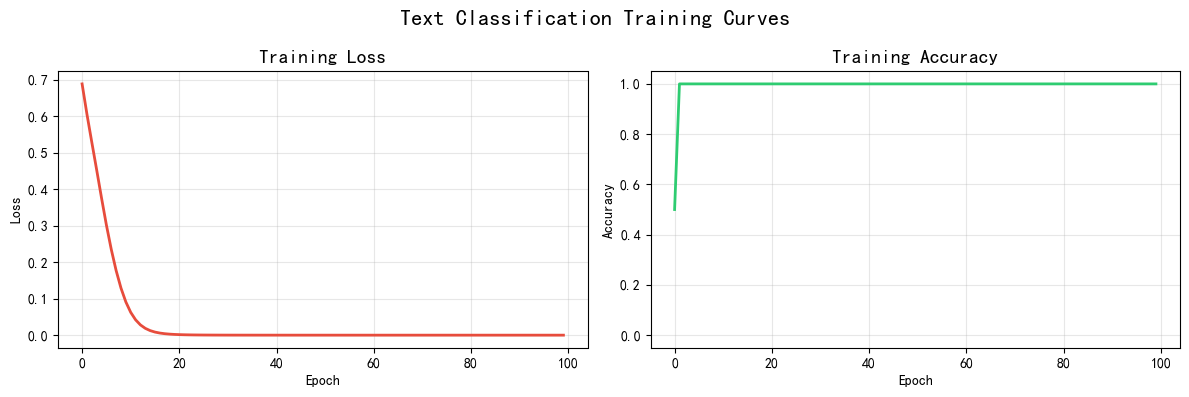

===== 训练过程可视化 =====


In [16]:
# ===== 训练过程可视化 =====
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 记录训练曲线
model2 = TextClassifier(vocab_size, embed_dim, num_classes)
optimizer2 = optim.Adam(model2.parameters(), lr=0.05)

losses = []
accuracies = []

for epoch in range(100):
    optimizer2.zero_grad()
    outputs = model2(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer2.step()
    
    losses.append(loss.item())
    preds = outputs.argmax(dim=1)
    acc = (preds == y_train).float().mean().item()
    accuracies.append(acc)

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses, color='#E74C3C', linewidth=2)
axes[0].set_title('Training Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(accuracies, color='#2ECC71', linewidth=2)
axes[1].set_title('Training Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Text Classification Training Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("===== 训练过程可视化 =====")

---

## 六、本节知识图谱

```
                    词的表示
                        │
         ┌──────────────┼──────────────┐
         ▼              ▼              ▼
    离散表示       分布式表示       传统特征
    One-Hot    Word2Vec/GloVe     BoW/TF-IDF
   (稀疏/高维)  FastText         (稀疏/统计)
               (稠密/低维)
                    │
                    ▼
            PyTorch nn.Embedding
            (可学习查找表)
                    │
                    ▼
            ┌──── 文本分类流水线 ────┐
            │ 文本→分词→ID→嵌入→池化 │
            │ →Linear→Softmax→预测   │
            └────────────────────────┘
```

---

## 📝 练习题

### 练习 1：One-Hot vs 嵌入向量（基础）

给定词汇表 `['apple', 'banana', 'orange', 'grape']`：
1. 写出 `banana` 的 One-Hot 编码
2. 计算 `apple` 和 `orange` 的 One-Hot 编码的余弦相似度
3. 解释为什么 One-Hot 无法区分语义相似性

---

### 练习 2：TF-IDF 计算（进阶）

给定以下文档集：

```
Doc1: "the cat sat on the mat"
Doc2: "the dog played in the park"
Doc3: "the cat and the dog"
```

要求：
1. 计算每个词的 TF 和 IDF
2. 构建完整的 TF-IDF 矩阵
3. 分析 `cat`、`dog`、`the` 的 TF-IDF 值，解释为何 `the` 的 TF-IDF 最低

---

### 练习 3：nn.Embedding 文本分类（综合）

扩展本节的文本分类模型：

1. 增加训练数据（至少 20 条样本，包含正面和负面评价）
2. 将均值池化改为 **最大池化**（`embedded.max(dim=1)`）
3. 添加一层隐藏层（`Linear(d → h)` + `ReLU` + `Linear(h → C)`）
4. 训练 200 轮，绘制 Loss 和 Accuracy 曲线

---

### 练习 4：Skip-gram 训练（挑战）

修改本节的 Skip-gram 简化实现：

1. 使用更大的语料（至少 50 个句子）
2. 加入**负采样**：对每个正样本 $(w_c, w_p)$，随机采样 $k=3$ 个负样本 $(w_c, w_n)$
3. 使用 Binary Cross Entropy Loss
4. 训练后找出与 "machine" 最相似的 5 个词